<a href="https://colab.research.google.com/github/niRmana11/food-classification-deep-learning/blob/feature%2Fnirmana-custom-cnn/03_custom_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Environment Sync & Auto-Dataset Check

import os, sys
from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

REPO_NAME = "food-classification-deep-learning"
BRANCH = "feature/nirmana-custom-cnn"

if 'google.colab' in sys.modules:
    print("[INFO] Running in Google Colab environment.")
    if not os.path.exists(f"/content/{REPO_NAME}"):
        !git clone -b {BRANCH} https://github.com/niRmana11/food-classification-deep-learning.git
        %cd /content/{REPO_NAME}
    else:
        %cd /content/{REPO_NAME}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if f"/content/{REPO_NAME}" not in sys.path:
        sys.path.insert(0, f"/content/{REPO_NAME}")

# Verify GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"[SUCCESS] GPU active: {gpus[0].name}")
    !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv
else:
    print("[WARNING] No GPU detected! Go to Runtime -> Change runtime type -> T4 GPU")

# Auto-download dataset if missing
if not os.path.exists("data/raw/food-101/images"):
    !python -m src.data.download_food101


[INFO] Running in Google Colab environment.
Cloning into 'food-classification-deep-learning'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 151 (delta 63), reused 120 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (151/151), 20.52 MiB | 23.50 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/food-classification-deep-learning
[SUCCESS] GPU active: /physical_device:GPU:0
name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 14910 MiB
[INFO] Downloading Food-101 (~5GB) from http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz ...
[NOTE] On Google Colab, this takes ~1-2 minutes over cloud connection.
food-101.tar.gz: 5.00GB [03:42, 22.5MB/s]                
[INFO] Download completed successfully.
[INFO] Extracting archive to /content/food-classification-deep-learning/data/raw ...
/content/food-classification-deep-learning/src/data/download_food101.py:48

In [2]:
# Instantiate Standardized Data Loaders

from src.preprocessing.data_loader import get_food101_datasets
from src.models.custom_cnn import build_custom_cnn

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

print("[INFO] Loading datasets via shared factory...")
train_ds, val_ds, test_ds = get_food101_datasets(
    data_dir="data/raw/food-101",
    splits_dir="data/splits",
    model_type="custom_cnn",   # Automatically applies [0.0, 1.0] scaling
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

print("[SUCCESS] Train, Validation, and Test pipelines loaded successfully.")


[INFO] Loading datasets via shared factory...
[SUCCESS] Train, Validation, and Test pipelines loaded successfully.


In [3]:
# Model Instantiation & Checkpoints

RESULTS_DIR = Path("results/custom_cnn")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

model = build_custom_cnn(input_shape=(224, 224, 3), num_classes=101, learning_rate=0.001)

# Save architecture summary to model_summary.txt
with open(RESULTS_DIR / "model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

# Standardized Callbacks
callbacks = [
    # Stop if validation loss doesn't improve for 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when plateauing
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
    # Log epoch history to CSV
    tf.keras.callbacks.CSVLogger(
        filename=str(RESULTS_DIR / "history.csv"),
        separator=",",
        append=False
    )
]

print("[INFO] Callbacks configured. Ready for training.")
model.summary()


[INFO] Callbacks configured. Ready for training.


Model: "Custom_Food101_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4_1 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             

 Total params: 678,085 (2.59 MB)

 Trainable params: 675,653 (2.58 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [4]:
# Execute Training on Colab GPU

EPOCHS = 20

print(f"[INFO] Starting Custom CNN training for up to {EPOCHS} epochs...")
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

total_training_time = time.time() - start_time
print(f"\n[SUCCESS] Training finished in {total_training_time:.1f} seconds ({total_training_time/60:.1f} minutes).")


[INFO] Starting Custom CNN training for up to 20 epochs...
Epoch 1/20
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 759s 345ms/step - accuracy: 0.0484 - loss: 4.4415 - top_5_accuracy: 0.1724 - val_accuracy: 0.0793 - val_loss: 4.1284 - val_top_5_accuracy: 0.2533 - learning_rate: 0.0010
Epoch 2/20
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 720s 337ms/step - accuracy: 0.1148 - loss: 3.8113 - top_5_accuracy: 0.3327 - val_accuracy: 0.1209 - val_loss: 3.8483 - val_top_5_accuracy: 0.3257 - learning_rate: 0.0010
Epoch 3/20
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 719s 337ms/step - accuracy: 0.1831 - loss: 3.4231 - top_5_accuracy: 0.4419 - val_accuracy: 0.1483 - val_loss: 3.8689 - val_top_5_accuracy: 0.3806 - learning_rate: 0.0010
Epoch 4/20
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 729s 342ms/step - accuracy: 0.2396 - loss: 3.1357 - top_5_accuracy: 0.5224 - val_accuracy: 0.1848 - val_loss: 3.5403 - val_top_5_accuracy: 0.4536 - learning_rate: 0.0010
Epoch 5/20
2131/2131 ━━━━━━━━━━━━━━━━━━━━ 729s 342ms/step - accuracy: 0.2856 - loss: 2.9066 -

In [5]:
print("Is model in memory?", 'model' in globals())


Is model in memory? True


In [7]:
# Save Weights Locally & Permanently Backup to Google Drive

import os
import shutil
from google.colab import drive

# 1. Save weights locally in the results folder
WEIGHTS_LOCAL = "results/custom_cnn/custom_cnn_best.weights.h5"
model.save_weights(WEIGHTS_LOCAL)
print(f"[SUCCESS] Weights saved locally at: {WEIGHTS_LOCAL}")

# 2. Backup to Google Drive so they are never lost if Colab disconnects
print("[INFO] Mounting Google Drive for permanent backup...")
drive.mount('/content/drive')

GDRIVE_DIR = "/content/drive/MyDrive/food101_checkpoints"
os.makedirs(GDRIVE_DIR, exist_ok=True)
shutil.copy(WEIGHTS_LOCAL, GDRIVE_DIR)
print(f"[SUCCESS] Weights permanently backed up to: {GDRIVE_DIR}/custom_cnn_best.weights.h5")


[SUCCESS] Weights saved locally at: results/custom_cnn/custom_cnn_best.weights.h5
[INFO] Mounting Google Drive for permanent backup...
Mounted at /content/drive
[SUCCESS] Weights permanently backed up to: /content/drive/MyDrive/food101_checkpoints/custom_cnn_best.weights.h5


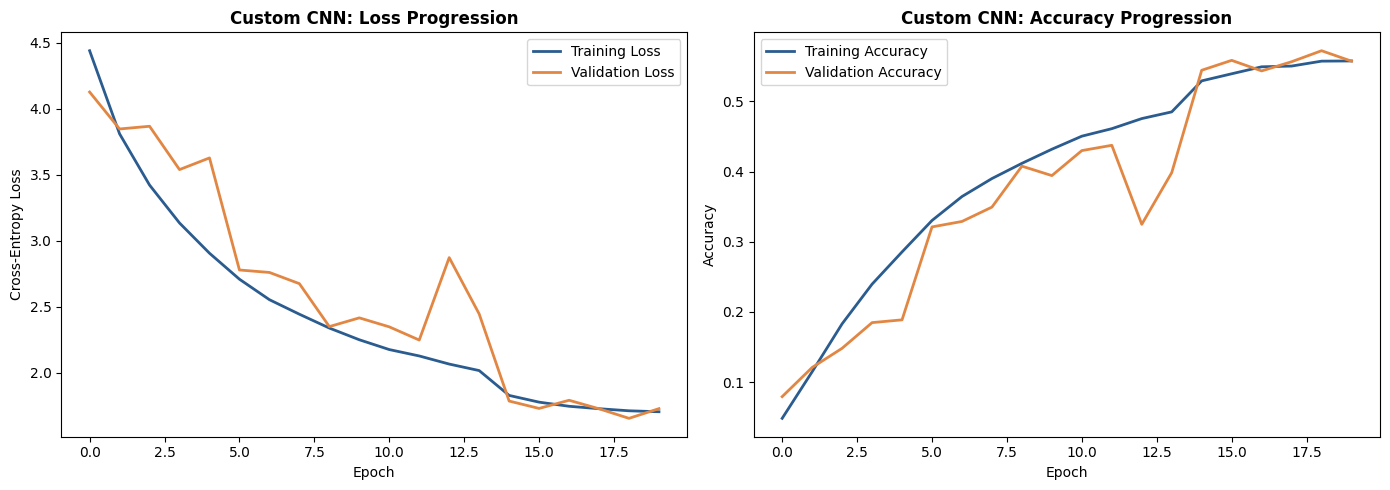

[INFO] Evaluating best restored weights on the UNSEEN test set...
790/790 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.6169 - loss: 1.4441 - top_5_accuracy: 0.8619
[INFO] Measuring inference latency (ms/image)...
CUSTOM CNN FINAL EVALUATION SUMMARY
model_name                         : Custom_CNN
total_parameters                   : 678085
trainable_parameters               : 675653
training_time_seconds              : 14339.84
inference_latency_ms_per_image     : 5.9
final_val_loss                     : 1.6548
final_val_accuracy                 : 0.5723
final_test_loss                    : 1.4441
final_test_accuracy                : 0.6169


In [8]:
# Plot Training Curves (Figure for Report)

hist_df = pd.DataFrame(history.history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
ax1.plot(hist_df["loss"], label="Training Loss", color="#2b5c8f", linewidth=2)
ax1.plot(hist_df["val_loss"], label="Validation Loss", color="#e28743", linewidth=2)
ax1.set_title("Custom CNN: Loss Progression", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=10)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=10)
ax1.legend()

# Accuracy Plot
ax1_acc = ax2.plot(hist_df["accuracy"], label="Training Accuracy", color="#2b5c8f", linewidth=2)
ax2.plot(hist_df["val_accuracy"], label="Validation Accuracy", color="#e28743", linewidth=2)
ax2.set_title("Custom CNN: Accuracy Progression", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=10)
ax2.set_ylabel("Accuracy", fontsize=10)
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=300)
plt.show()


# Final Test Set Evaluation & Export metrics.json
print("[INFO] Evaluating best restored weights on the UNSEEN test set...")
test_results = model.evaluate(test_ds)

# Profile inference latency over 500 images
print("[INFO] Measuring inference latency (ms/image)...")
latencies = []
for imgs, _ in test_ds.take(16): # ~512 images
    t0 = time.time()
    _ = model(imgs, training=False)
    latencies.append((time.time() - t0) / len(imgs) * 1000)
avg_latency = float(np.mean(latencies))

metrics_data = {
    "model_name": "Custom_CNN",
    "total_parameters": int(model.count_params()),
    "trainable_parameters": int(sum([tf.size(w).numpy() for w in model.trainable_weights])),
    "training_time_seconds": round(total_training_time, 2),
    "inference_latency_ms_per_image": round(avg_latency, 2),
    "final_val_loss": round(float(hist_df["val_loss"].min()), 4),
    "final_val_accuracy": round(float(hist_df["val_accuracy"].max()), 4),
    "final_test_loss": round(float(test_results[0]), 4),
    "final_test_accuracy": round(float(test_results[1]), 4)
}

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_data, f, indent=2)


print("CUSTOM CNN FINAL EVALUATION SUMMARY")
for k, v in metrics_data.items():
    print(f"{k:<35}: {v}")



[INFO] Computing predictions on the test set for Confusion Matrix...
[SAVED] results/custom_cnn/classification_report.json


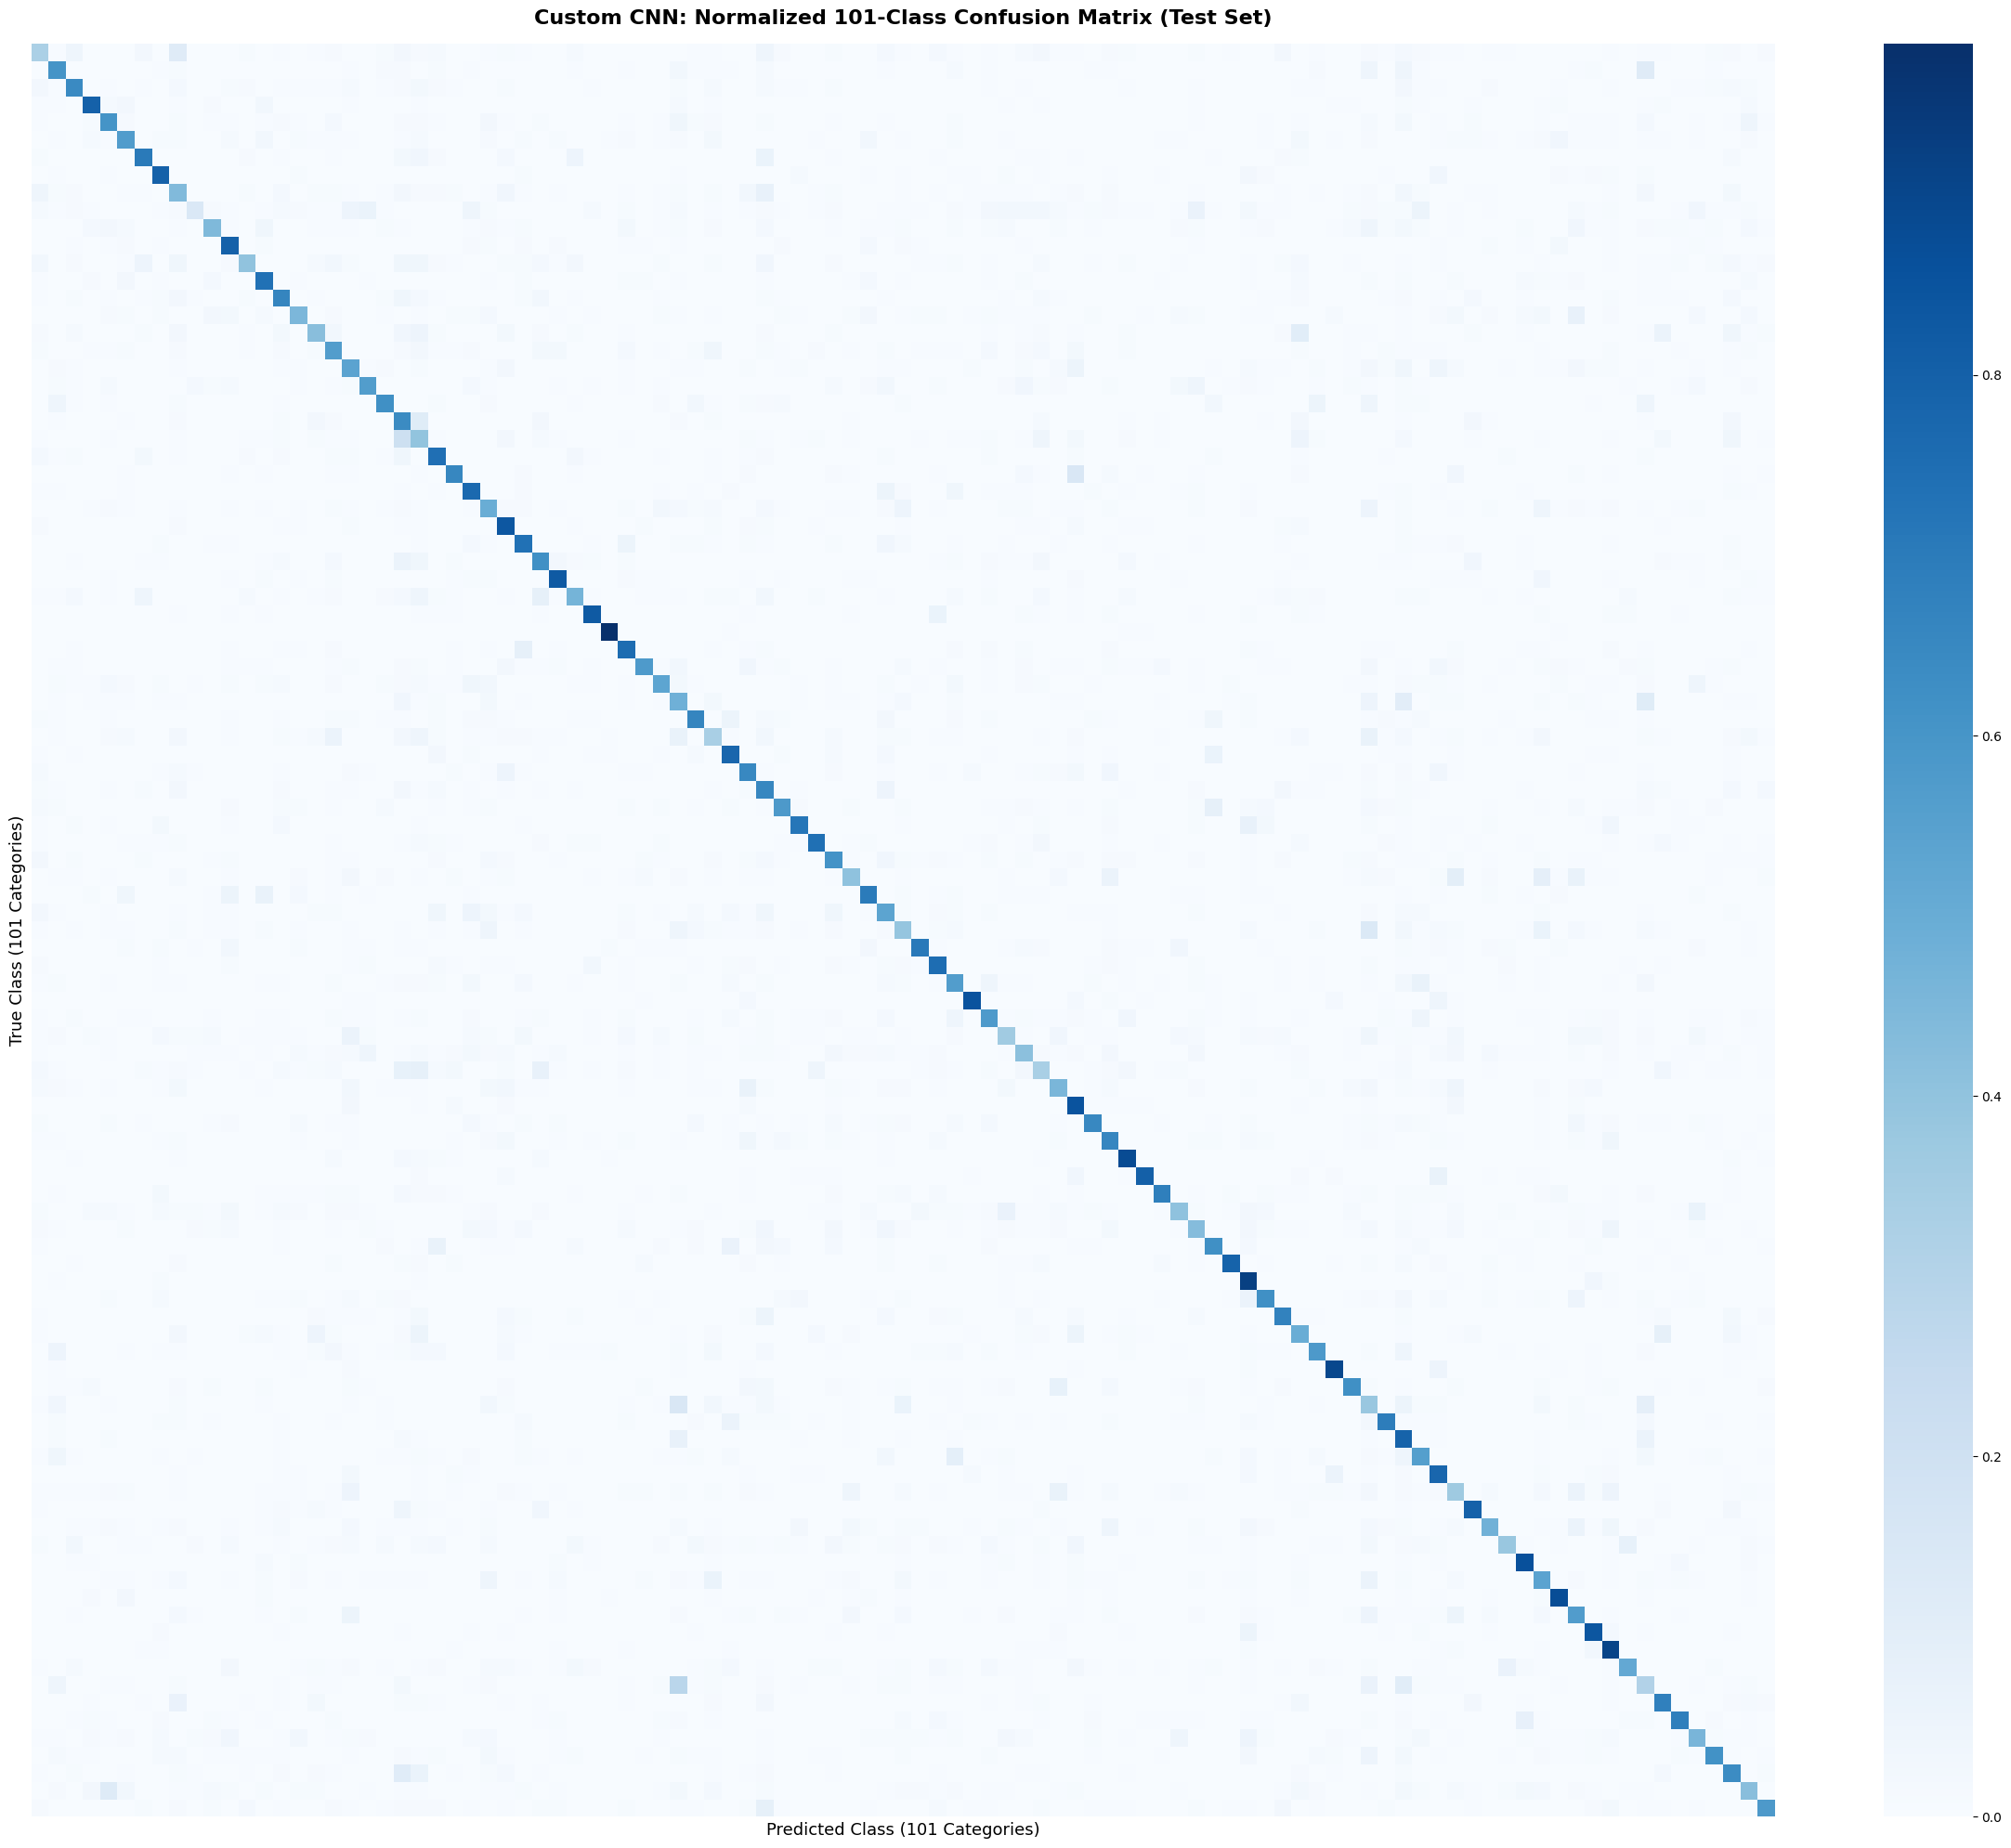

[SAVED] results/custom_cnn/confusion_matrix.png


In [9]:

# Generate High-Resolution Confusion Matrix & Classification Report

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("[INFO] Computing predictions on the test set for Confusion Matrix...")

# Get ground truth labels and predictions
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Load class names
with open("data/splits/classes.txt", "r") as f:
    class_names = [line.strip() for line in f if line.strip()]

# 2. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
with open(RESULTS_DIR / "classification_report.json", "w") as f:
    json.dump(report, f, indent=2)
print(f"[SAVED] {RESULTS_DIR / 'classification_report.json'}")

# 3. High-Resolution Normalized Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(24, 20))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False,
    cbar=True,
    rasterized=True
)
plt.title("Custom CNN: Normalized 101-Class Confusion Matrix (Test Set)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Predicted Class (101 Categories)", fontsize=13)
plt.ylabel("True Class (101 Categories)", fontsize=13)
plt.tight_layout()

cm_path = RESULTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"[SAVED] {cm_path}")
